In [1]:
library(tidyverse)
library(glue)

Warning message:
“package ‘tibble’ was built under R version 4.2.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
sessionInfo()

R version 4.2.1 (2022-06-23)
Platform: x86_64-apple-darwin13.4.0 (64-bit)
Running under: macOS Big Sur ... 10.16

Matrix products: default
BLAS/LAPACK: /Users/joonklaps/opt/anaconda3/lib/libopenblasp-r0.3.20.dylib

locale:
[1] C/C.UTF-8/C/C/C/C

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] glue_1.7.0      lubridate_1.9.3 forcats_1.0.0   stringr_1.5.1  
 [5] dplyr_1.1.4     purrr_1.0.2     readr_2.1.5     tidyr_1.3.1    
 [9] tibble_3.2.1    ggplot2_3.5.2   tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] pillar_1.10.2      compiler_4.2.1     RColorBrewer_1.1-3 base64enc_0.1-3   
 [5] tools_4.2.1        digest_0.6.36      uuid_1.2-0         timechange_0.3.0  
 [9] jsonlite_1.8.8     evaluate_1.0.3     lifecycle_1.0.4    gtable_0.3.6      
[13] pkgconfig_2.0.3    rlang_1.1.4        IRdisplay_1.1      cli_3.6.3         
[17] IRkernel_1.3.2     fastmap_1.2.0      repr_1.1.7         withr_3.0

In [8]:
fident_window_to_digits <- function(x) {
  rng <- str_match(as.character(x), "\\[?(0?\\.\\d+),\\s*(1|0?\\.\\d+)\\]")
  lo <- as.numeric(rng[, 2])
  hi <- as.numeric(rng[, 3])
  sprintf("%02d%02d", round(lo * 100), round(hi * 100))
}

In [40]:
consensus_to_original <- read_tsv("./data-preparation/global-alignment/combined_alignment_stats.tsv")%>%
    mutate(
        reference_distance = gsub("^(LVE\\d{5}-[RVDB0-9]{4})_.*", "\\1", seq1_id),
        index = gsub("^(LVE\\d{5}-[RVDB0-9]{4})_(.*).consensus.bcftools", "\\2", seq1_id),
        segment = gsub(".*_(S|L|M)$", "\\1", seq2_id))
reference_to_original <- read_tsv("./data-preparation/selected-references/selected_references.tsv")%>%
    mutate(reference_distance = glue("{query}-{fident_window_to_digits(fident_window)}"))

contig_table <- read_tsv("viralmetagenome-out/combined/contigs_overview.tsv")

Rows: 252 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): seq1_id, seq2_id
dbl (11): alignment_length, comparable_sites, matches, mismatches, mismatch_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 125 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (4): query, target, segment, fident_window
dbl (12): fident, alnlen, mismatch, gapopen, qstart, qend, qlen, tstart, ten...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 464 Columns: 173
── Column specification ───────────────────────────────

In [25]:
dim(consensus_to_original)

[1] 252  16

In [26]:
dim(contig_table)

[1] 464 173

In [52]:
head(reference_to_original)

query,target,fident,alnlen,mismatch,gapopen,qstart,qend,qlen,tstart,tend,tlen,evalue,bits,segment,fident_window,reference_distance
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<glue>
LVE00045,MT199231.1,0.660,1981,670,0,2083,113,7241,5163,7143,7286,3.442e-304,1050,L,"[0.64,0.66]",LVE00045-6466
LVE00045,MT199235.1,0.676,1577,511,0,2083,507,7241,5174,6750,7289,5.614e-252,870,L,"(0.66,0.68]",LVE00045-6668
LVE00045,OR041677.1,0.684,3251,1026,0,3317,67,3407,100,3347,3402,0.000e+00,2308,S,"(0.68,0.7]",LVE00045-6870
LVE00045,OR041684.1,0.736,3251,857,0,3317,67,3407,1,3248,3303,0.000e+00,2512,S,"(0.72,0.74]",LVE00045-7274
LVE00045,MK117836.1,0.753,6779,1674,0,47,6824,7241,64,6842,7264,0.000e+00,7994,L,"(0.74,0.76]",LVE00045-7476
LVE00045,ON569374.1,0.779,6780,1498,0,47,6824,7241,23,6802,7167,0.000e+00,8301,L,"(0.76,0.78]",LVE00045-7678


In [ ]:
 merge(consensus_to_original, contig_table, by=c("index","reference_distance"), all.x=TRUE)%>%head()


,index,reference_distance,seq1_id,seq2_id,alignment_length,comparable_sites,matches,mismatches,mismatch_rate,seq1_length,⋯,(general_stats) mosdepth 5X coverage,(general_stats) mosdepth 10X coverage,(general_stats) mosdepth 50X coverage,(general_stats) mosdepth 100X coverage,(general_stats) mosdepth 200X coverage,(general_stats) mosdepth 500X coverage,(general_stats) mosdepth 750X coverage,(general_stats) mosdepth 1000X coverage,(checkv) warnings,(failed_mapped) mapped reads
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
1,LVE00045_cl0_it2,LVE00045-6466,LVE00045-6466_LVE00045_cl0_it2.consensus_bcftools,_R_LVE00045_S,3443,1831,1798,33,0.018023,1891,⋯,100,100,60,7,0,0,0,0,NA,NA
2,LVE00045_cl0_it2,LVE00045-6668,LVE00045-6668_LVE00045_cl0_it2.consensus_bcftools,_R_LVE00045_S,3443,1831,1798,33,0.018023,1891,⋯,100,100,60,7,0,0,0,0,NA,NA
3,LVE00045_cl0_it2,LVE00045-6870,LVE00045-6870_LVE00045_cl0_it2.consensus_bcftools,_R_LVE00045_S,3443,1831,1798,33,0.018023,1891,⋯,100,100,60,7,0,0,0,0,NA,NA
4,LVE00045_cl0_it2,LVE00045-7274,LVE00045-7274_LVE00045_cl0_it2.consensus_bcftools,_R_LVE00045_S,3443,1831,1798,33,0.018023,1891,⋯,100,100,60,7,0,0,0,0,NA,NA
5,LVE00045_cl0_it2,LVE00045-7476,LVE00045-7476_LVE00045_cl0_it2.consensus_bcftools,LVE00045_L,7264,5428,5425,3,0.000553,7263,⋯,81,75,27,5,0,0,0,0,low-confidence DTR,NA
6,LVE00045_cl0_it2,LVE00045-7678,LVE00045-7678_LVE00045_cl0_it2.consensus_bcftools,LVE00045_L,7242,5712,5712,0,0.000000,7167,⋯,85,80,30,5,0,0,0,0,no viral genes detected; low-confidence DTR,NA


In [55]:
dim(reference_to_original)

[1] 125  17

In [111]:
consensus_vs_reference <- left_join(
    merge(consensus_to_original, contig_table, by=c("index","reference_distance")),
    reference_to_original, by=c("reference_distance", "segment"), suffix=c("_consensus", "_reference"))%>%
    mutate(
        is_external_reference_scaffold = ifelse(grepl("NODE|k\\d{3}", `(cluster) centroid`), FALSE, TRUE),
        is_RVDB_reference = ifelse(grepl("RVDB", reference_distance), TRUE, FALSE),
        fident = ifelse(is_RVDB_reference, 1, fident)
    )

dim(consensus_vs_reference)

[1] 252 204

In [112]:
head(consensus_vs_reference)

,index,reference_distance,seq1_id,seq2_id,alignment_length,comparable_sites,matches,mismatches,mismatch_rate,seq1_length,⋯,qend,qlen,tstart,tend,tlen,evalue,bits,fident_window,is_external_reference_scaffold,is_RVDB_reference
,<chr>,<glue>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>
1,LVE00045_cl0_it2,LVE00045-6466,LVE00045-6466_LVE00045_cl0_it2.consensus_bcftools,_R_LVE00045_S,3443,1831,1798,33,0.018023,1891,⋯,NA,NA,NA,NA,NA,NA,NA,NA,FALSE,FALSE
2,LVE00045_cl0_it2,LVE00045-6668,LVE00045-6668_LVE00045_cl0_it2.consensus_bcftools,_R_LVE00045_S,3443,1831,1798,33,0.018023,1891,⋯,NA,NA,NA,NA,NA,NA,NA,NA,FALSE,FALSE
3,LVE00045_cl0_it2,LVE00045-6870,LVE00045-6870_LVE00045_cl0_it2.consensus_bcftools,_R_LVE00045_S,3443,1831,1798,33,0.018023,1891,⋯,67,3407,100,3347,3402,0,2308,"(0.68,0.7]",FALSE,FALSE
4,LVE00045_cl0_it2,LVE00045-7274,LVE00045-7274_LVE00045_cl0_it2.consensus_bcftools,_R_LVE00045_S,3443,1831,1798,33,0.018023,1891,⋯,67,3407,1,3248,3303,0,2512,"(0.72,0.74]",FALSE,FALSE
5,LVE00045_cl0_it2,LVE00045-7476,LVE00045-7476_LVE00045_cl0_it2.consensus_bcftools,LVE00045_L,7264,5428,5425,3,0.000553,7263,⋯,6824,7241,64,6842,7264,0,7994,"(0.74,0.76]",TRUE,FALSE
6,LVE00045_cl0_it2,LVE00045-7678,LVE00045-7678_LVE00045_cl0_it2.consensus_bcftools,LVE00045_L,7242,5712,5712,0,0.000000,7167,⋯,6824,7241,23,6802,7167,0,8301,"(0.76,0.78]",TRUE,FALSE


Warning message:
“Removed 164 rows containing missing values or values outside the scale range
(`geom_point()`).”


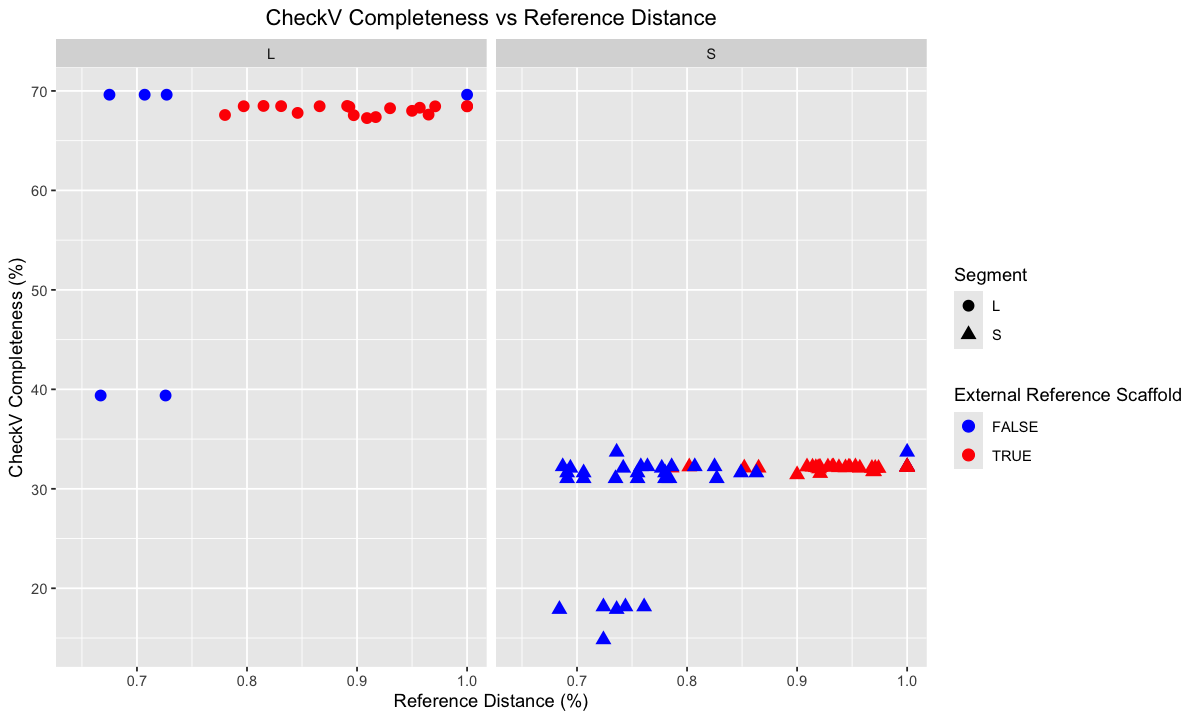

In [113]:
options(repr.plot.width=10, repr.plot.height=6)
ggplot(consensus_vs_reference, aes(x=fident, y=`(checkv) completeness`, color=is_external_reference_scaffold, shape=segment)) +
    geom_point(size=3) +
    facet_wrap(~segment) +
    labs(x="Reference Distance (%)", y="CheckV Completeness (%)", color="External Reference Scaffold", shape="Segment") +
    scale_color_manual(values=c("TRUE"="red", "FALSE"="blue")) +
    ggtitle("CheckV Completeness vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

Warning message:
“Removed 118 rows containing missing values or values outside the scale range
(`geom_point()`).”


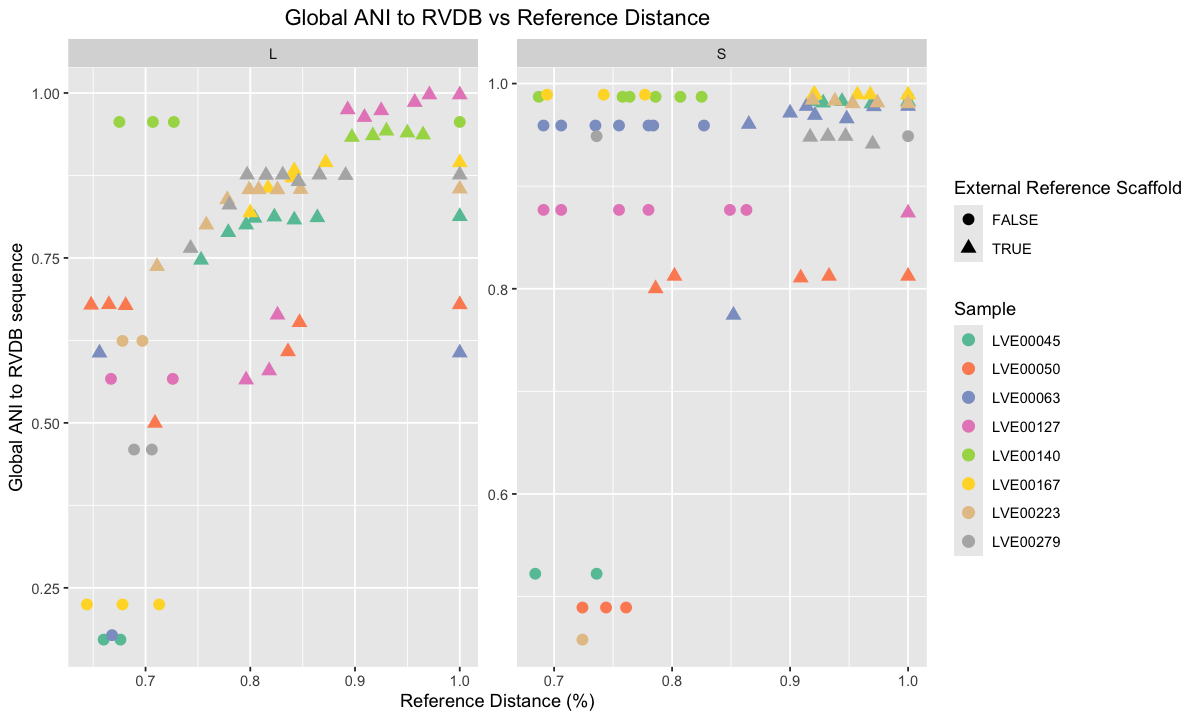

In [ ]:
ggplot(consensus_vs_reference, aes(x=fident, y=matches/alignment_length, color=sample, shape=is_external_reference_scaffold)) +
    geom_point(size=3) +
    facet_wrap(~segment, scales = "free") +
    labs(x="ANI of supplied scaffold reference to consensus (%)", y="Global ANI to RVDB sequence (%)", color="Sample", shape="External Reference Scaffold") +
    scale_color_brewer(palette = "Set2") +
    ggtitle("Global ANI to RVDB vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

Warning message:
“Removed 118 rows containing missing values or values outside the scale range
(`geom_point()`).”


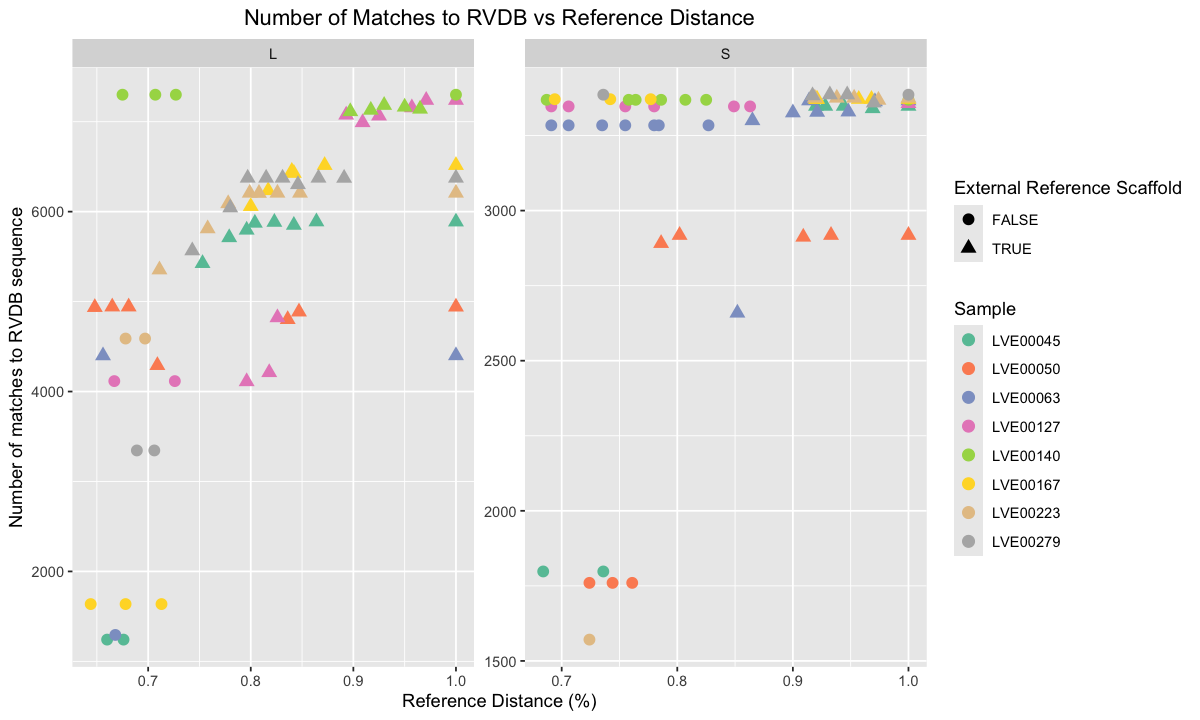

In [115]:
ggplot(consensus_vs_reference, aes(x=fident, y=matches, color=sample, shape=is_external_reference_scaffold)) +
    geom_point(size=3) +
    facet_wrap(~segment, scales = "free") +
    labs(x="Reference Distance (%)", y="Number of matches to RVDB sequence", color="Sample", shape="External Reference Scaffold") +
    scale_color_brewer(palette = "Set2") +
    ggtitle("Number of Matches to RVDB vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

Warning message:
“Removed 118 rows containing missing values or values outside the scale range
(`geom_point()`).”


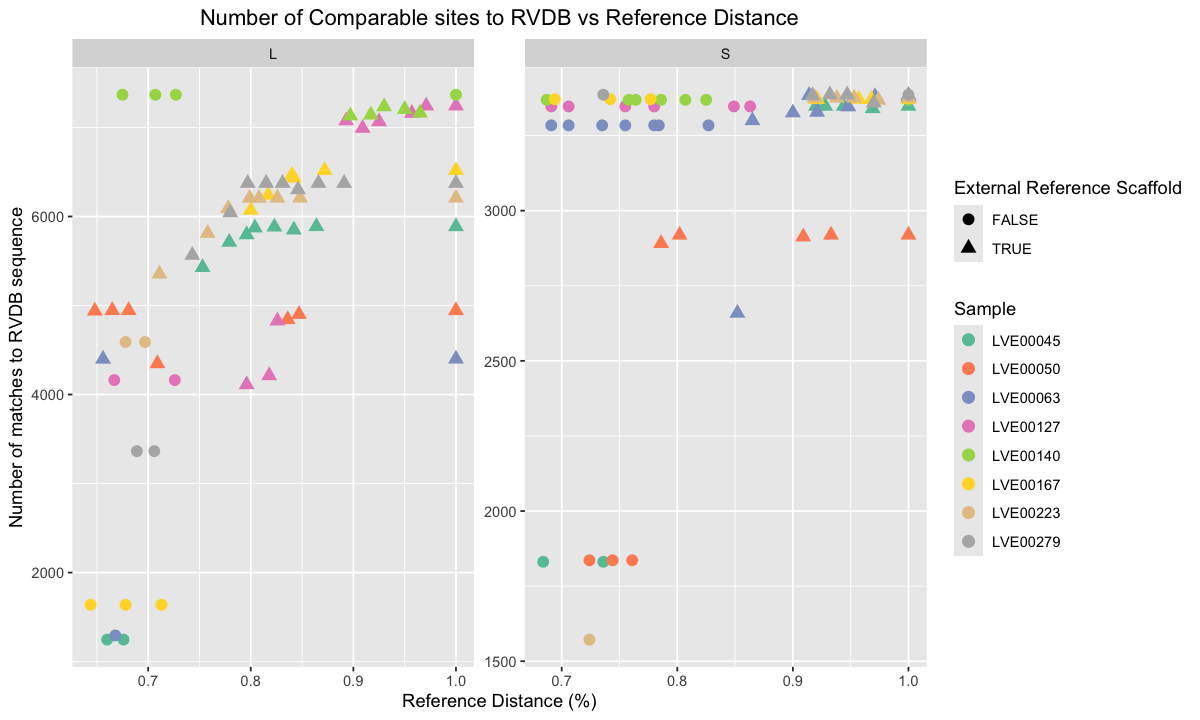

In [116]:
ggplot(consensus_vs_reference, aes(x=fident, y=comparable_sites, color=sample, shape=is_external_reference_scaffold)) +
    geom_point(size=3) +
    facet_wrap(~segment, scales = "free") +
    labs(x="Reference Distance (%)", y="Number of matches to RVDB sequence", color="Sample", shape="External Reference Scaffold") +
    scale_color_brewer(palette = "Set2") +
    ggtitle("Number of Comparable sites to RVDB vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

Warning message:
“Removed 118 rows containing missing values or values outside the scale range
(`geom_point()`).”


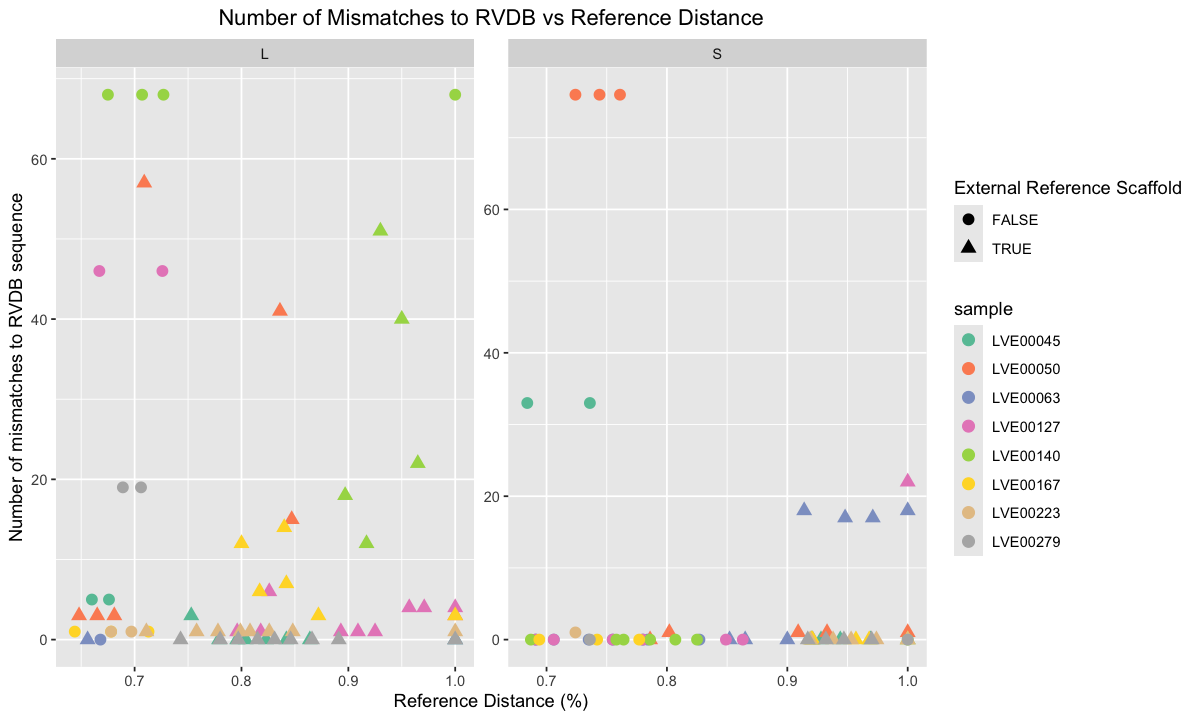

In [117]:
ggplot(consensus_vs_reference, aes(x=fident, y=mismatches,  color=sample, shape=is_external_reference_scaffold)) +
    geom_point(size=3) +
    facet_wrap(~segment, scales = "free") +
    labs(x="Reference Distance (%)", y="Number of mismatches to RVDB sequence", color="sample", shape="External Reference Scaffold") +
    scale_color_brewer(palette = "Set2") +
    ggtitle("Number of Mismatches to RVDB vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

Warning message:
“Removed 118 rows containing missing values or values outside the scale range
(`geom_point()`).”


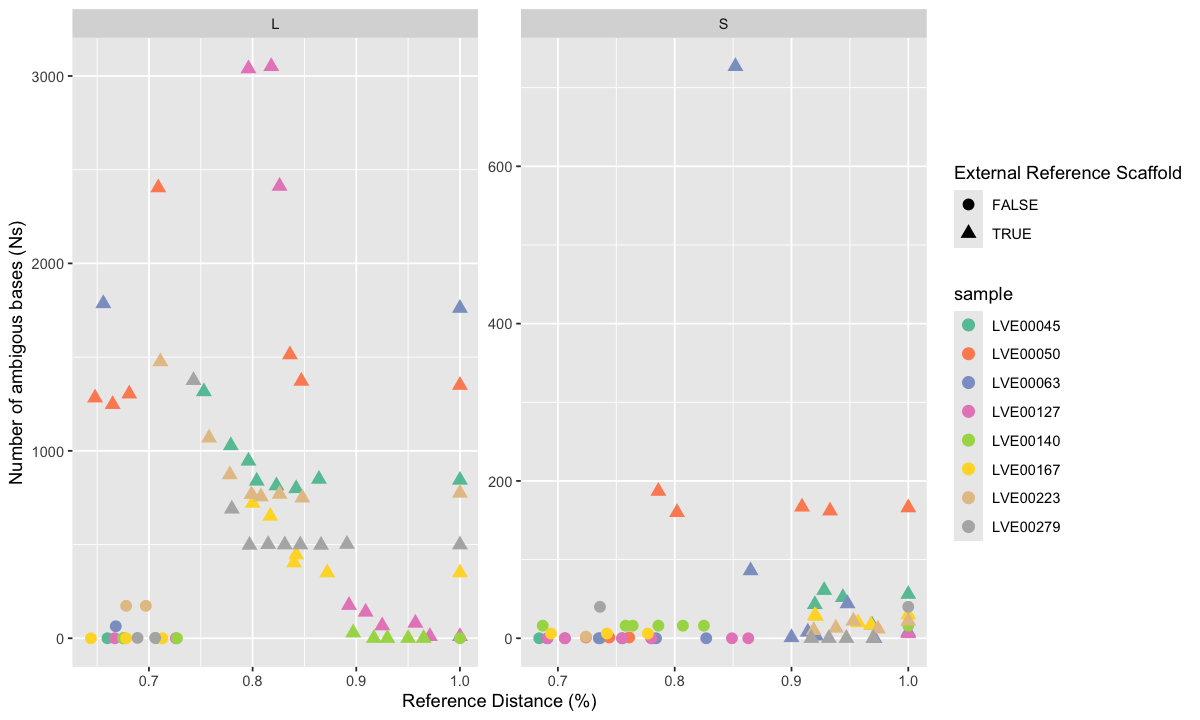

In [118]:
ggplot(consensus_vs_reference, aes(x=fident, y=seq1_Ns, color=sample, shape=is_external_reference_scaffold)) +
    geom_point(size=3) +
    facet_wrap(~segment, scales = "free") +
    labs(x="Reference Distance (%)", y="Number of ambigous bases (Ns)", color="sample", shape="External Reference Scaffold") +
    scale_color_brewer(palette = "Set2") +
    theme(plot.title = element_text(hjust = 0.5))

Warning message:
“Removed 118 rows containing missing values or values outside the scale range
(`geom_point()`).”


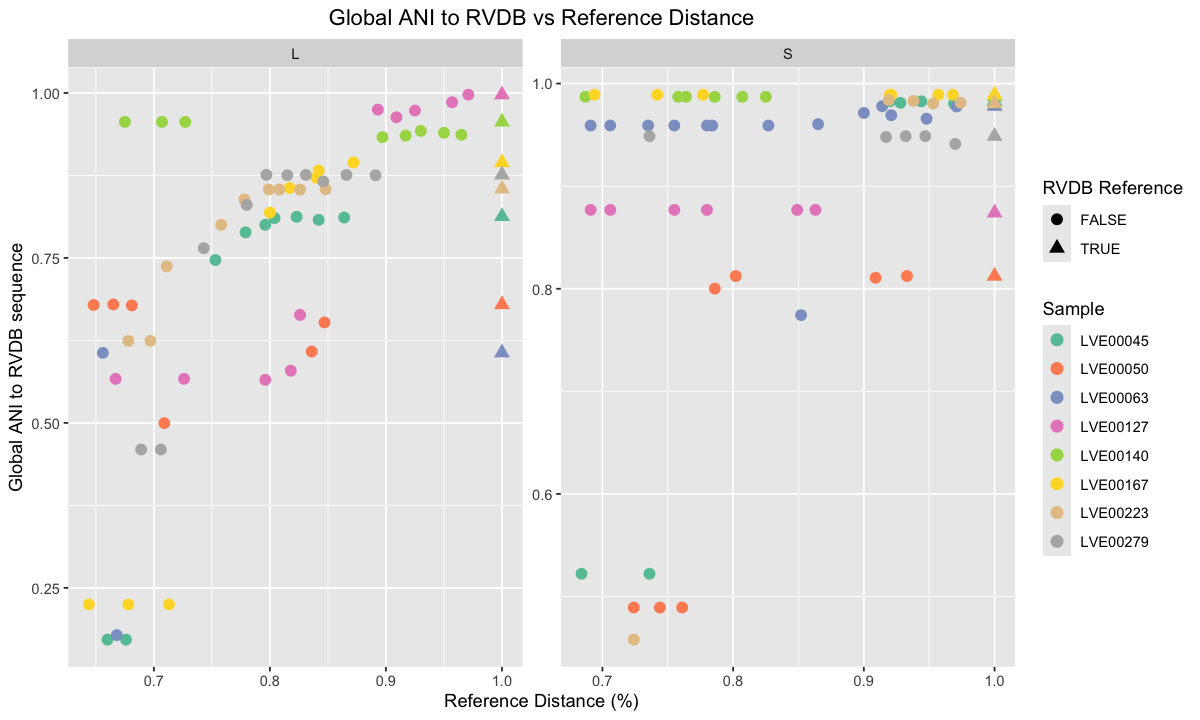

In [119]:
ggplot(consensus_vs_reference, aes(x=fident, y=matches/alignment_length, color=sample, shape=is_RVDB_reference)) +
    geom_point(size=3) +
    facet_wrap(~segment, scales = "free") +
    labs(x="Reference Distance (%)", y="Global ANI to RVDB sequence", color="Sample", shape="RVDB Reference") +
    scale_color_brewer(palette = "Set2") +
    ggtitle("Global ANI to RVDB vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))